# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [196]:
import math
import sys

In [197]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [198]:
# For this project, I pick the "Wine Quality" dataset from PMLB

# Load the red wine quality dataset from PMLB
redwine = pd.read_csv("https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/wine_quality_red/wine_quality_red.tsv.gz", sep="\t")

# Drop any rows with missing values
redwine = redwine.dropna()

# Display a random sample of 10 rows from the dataset 
redwine.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
1391,8.0,0.640,0.22,2.4,0.094,5.0,33.0,0.99612,3.37,0.58,11.0,5
668,10.0,0.730,0.43,2.3,0.059,15.0,31.0,0.99660,3.15,0.57,11.0,5
635,8.7,0.840,0.00,1.4,0.065,24.0,33.0,0.99540,3.27,0.55,9.7,5
808,7.4,0.530,0.12,1.9,0.165,4.0,12.0,0.99702,3.26,0.86,9.2,5
851,9.3,0.430,0.44,1.9,0.085,9.0,22.0,0.99708,3.28,0.55,9.5,5
350,10.7,0.670,0.22,2.7,0.107,17.0,34.0,1.00040,3.28,0.98,9.9,6
1321,5.0,0.740,0.00,1.2,0.041,16.0,46.0,0.99258,4.01,0.59,12.5,6
111,8.4,0.620,0.09,2.2,0.084,11.0,108.0,0.99640,3.15,0.66,9.8,5
1068,11.1,0.310,0.53,2.2,0.060,3.0,10.0,0.99572,3.02,0.83,10.9,7
1589,6.6,0.725,0.20,7.8,0.073,29.0,79.0,0.99770,3.29,0.54,9.2,5


### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

In [199]:
# Display the column names of the red wine quality dataset
redwine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'target'],
      dtype='object')

In [200]:
# Description of the columns:
print("Dataset shape:", redwine.shape)

# Basic statistics and missing values
print("\nBasic statistics:")
print(redwine.describe())

# Check for the total number of missing values
print("\nMissing values:", redwine.isnull().sum().sum())

# Count wine quality distribution 
print("\nWine quality distribution:")
print(redwine['target'].value_counts().sort_index())

Dataset shape: (1599, 12)

Basic statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min

#### Describe the dataset column names

This dataset provides **redwine testing and rating** records. It had 12 columns, which include **11 input Features** ('fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'), and **1 output Target** ('target').

Column "target" is renamed from the original "quality" column from the UI Irvine Machine Learning Repository

  - **Description**: Wine quality score based on sensory data, median of at least 3 evaluations made by wine experts.
  - **Value**: From 0 (very bad) to 10 (very excellent)

**Other column names and descriptions:**

  - **fixed acidity** - Non-volatile acids (tartaric, malic, citric) contributes to taste and stability

  - **volatile acidity** - Volatile acids (acetic acid) contributes to wine aroma

  - **citric acid** - attribute that adds freshness and flavor

  - **residual sugar** - attribute that affects wine sweetness

  - **chlorides** - attribute that affects wine saltiness

  - **free sulfur dioxide** - attribute that prevents microbial growth and oxidation

  - **total sulfur dioxide** - total amount of Sulfur (regulated by laws)

  - **density** - density of wine content

  - **pH** - Acidity level, measurements of wine's stability, colors and ages

  - **sulphates** - additive that increases fulfur dioxide levels

  - **alcohol** - Alcohol content by volume, contributor to wine's overall balance

*Referenced*:
Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.
   

### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

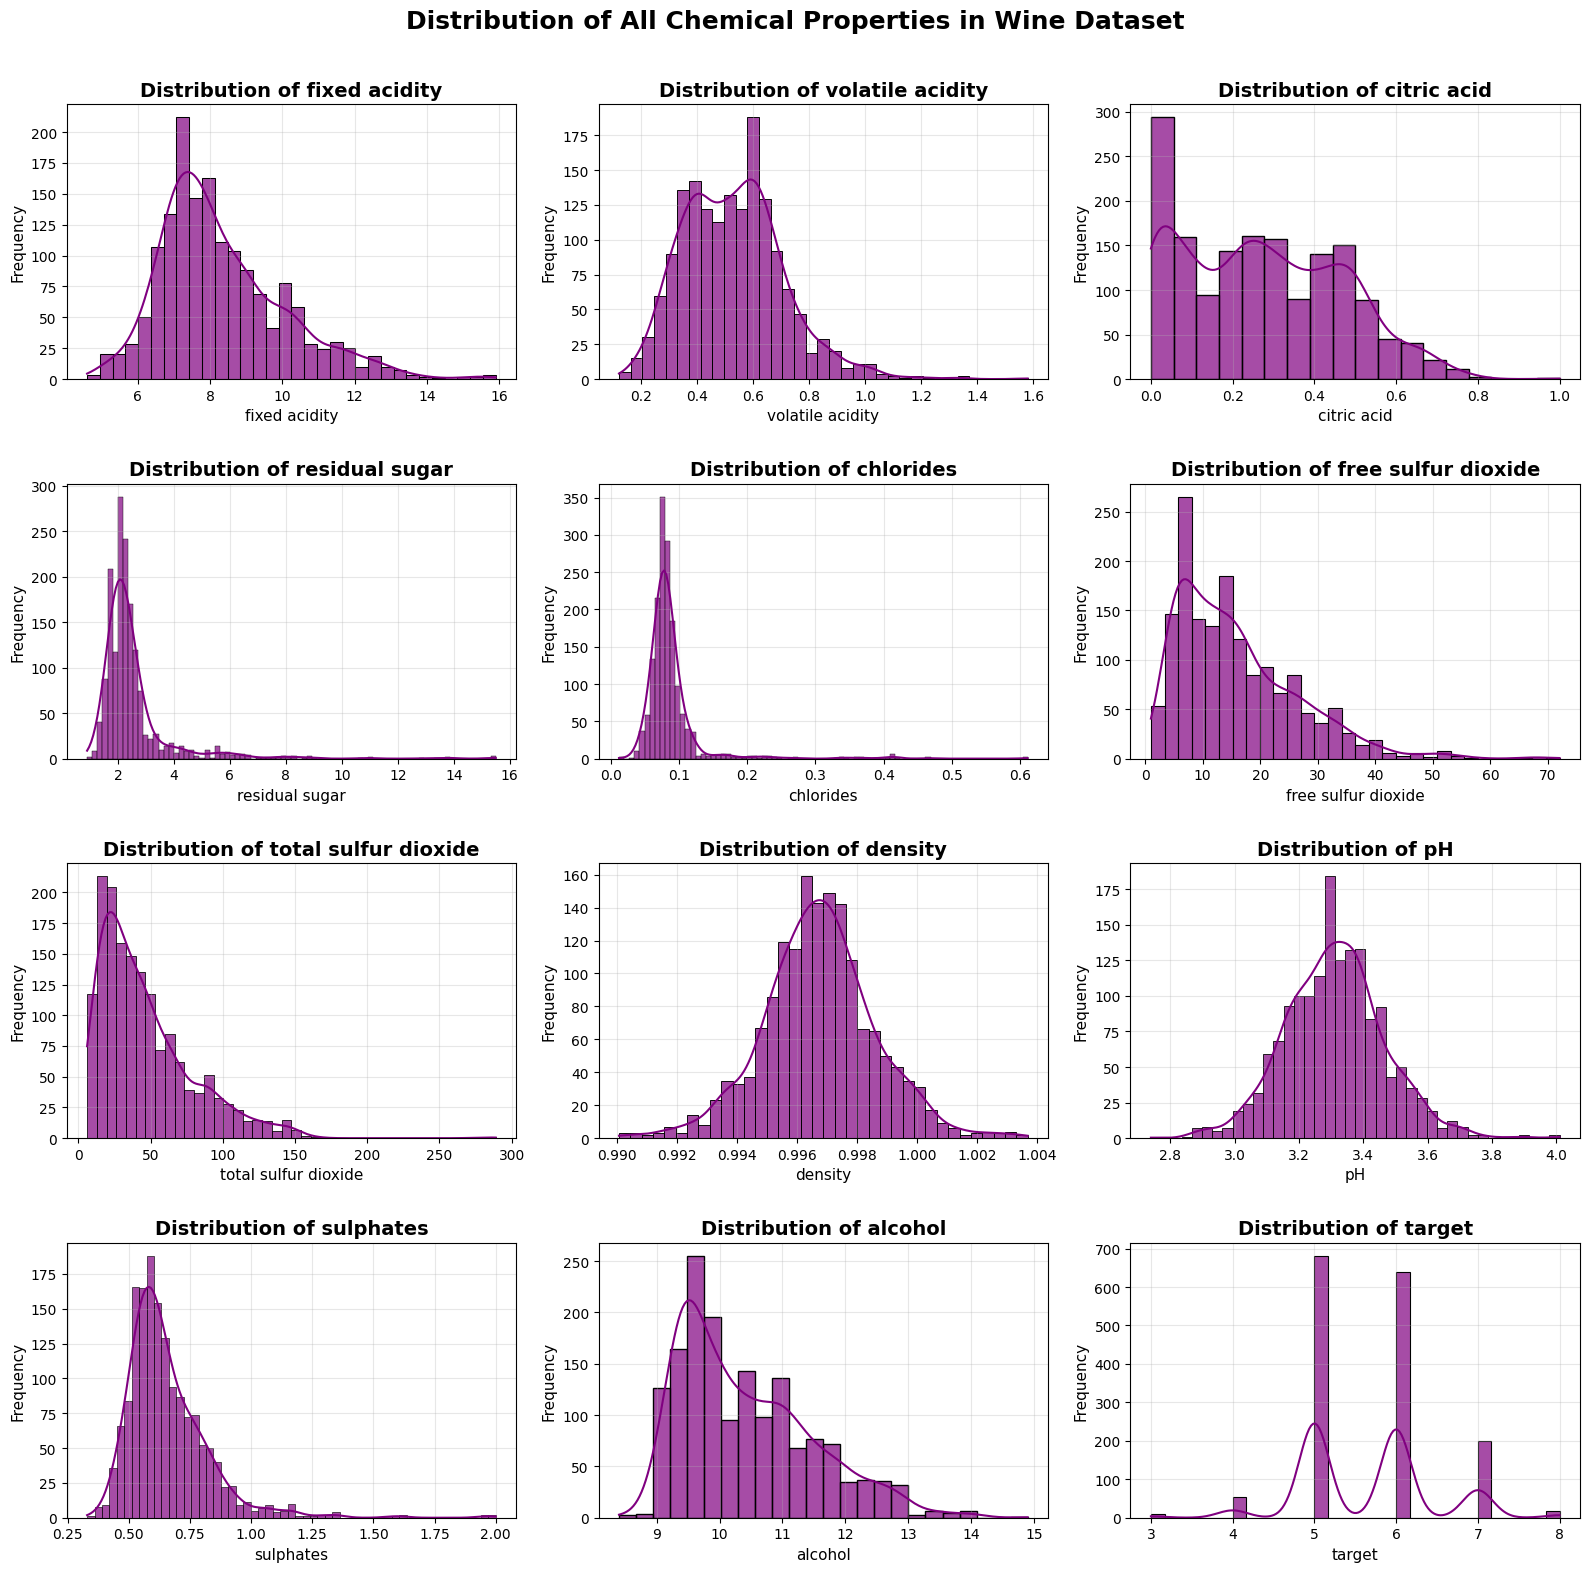

In [201]:
# All chemical columns
all_chemicals = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 
                 'density', 'pH', 'sulphates', 'alcohol', 'target']

# Create subplots
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

# Plot all chemicals + the target variable
for i, chem in enumerate(all_chemicals):
    ax = axes[i]
    sns.histplot(data=redwine, x=chem, ax=ax, kde=True, color='purple', alpha=0.7)
    ax.set_title(f'\nDistribution of {chem}', fontsize=14, weight='bold')
    ax.set_xlabel(chem, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution of All Chemical Properties in Wine Dataset\n', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution Analysis Summary for Wine Quality Dataset

| Column | Distribution | Why |
|--------|-------------|-----|
| fixed acidity | Close to be Normal | Chemical measurements cluster around a mean |
| volatile acidity | Close to be Normal | Most wines have low values, few have high acidity |
| citric acid | Right-skewed with spike at 0 | Many wines have zero or very low citric acid |
| residual sugar | Right-skewed | Most wines have low sugar, quite a few are sweet |
| chlorides | Right-skewed | Most wines have low salt content |
| free sulfur dioxide | Right-skewed | Typically low levels, a few has higher levels |
| total sulfur dioxide | Right-skewed | A few of them has high values, unsure why |
| density | Normal distribution | Closely related to alcohol and sugar content |
| pH | Approximately Normal | A few has 3.3 pH level, typically 3.0-3.7 range |
| sulphates | Right-skewed | Additive with typical low levels |
| alcohol | Approximately Normal | Typical range 9-11%. Some have high alcohol content |
| target | Target Column | Quality scores are discrete integers (3-8) |

### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

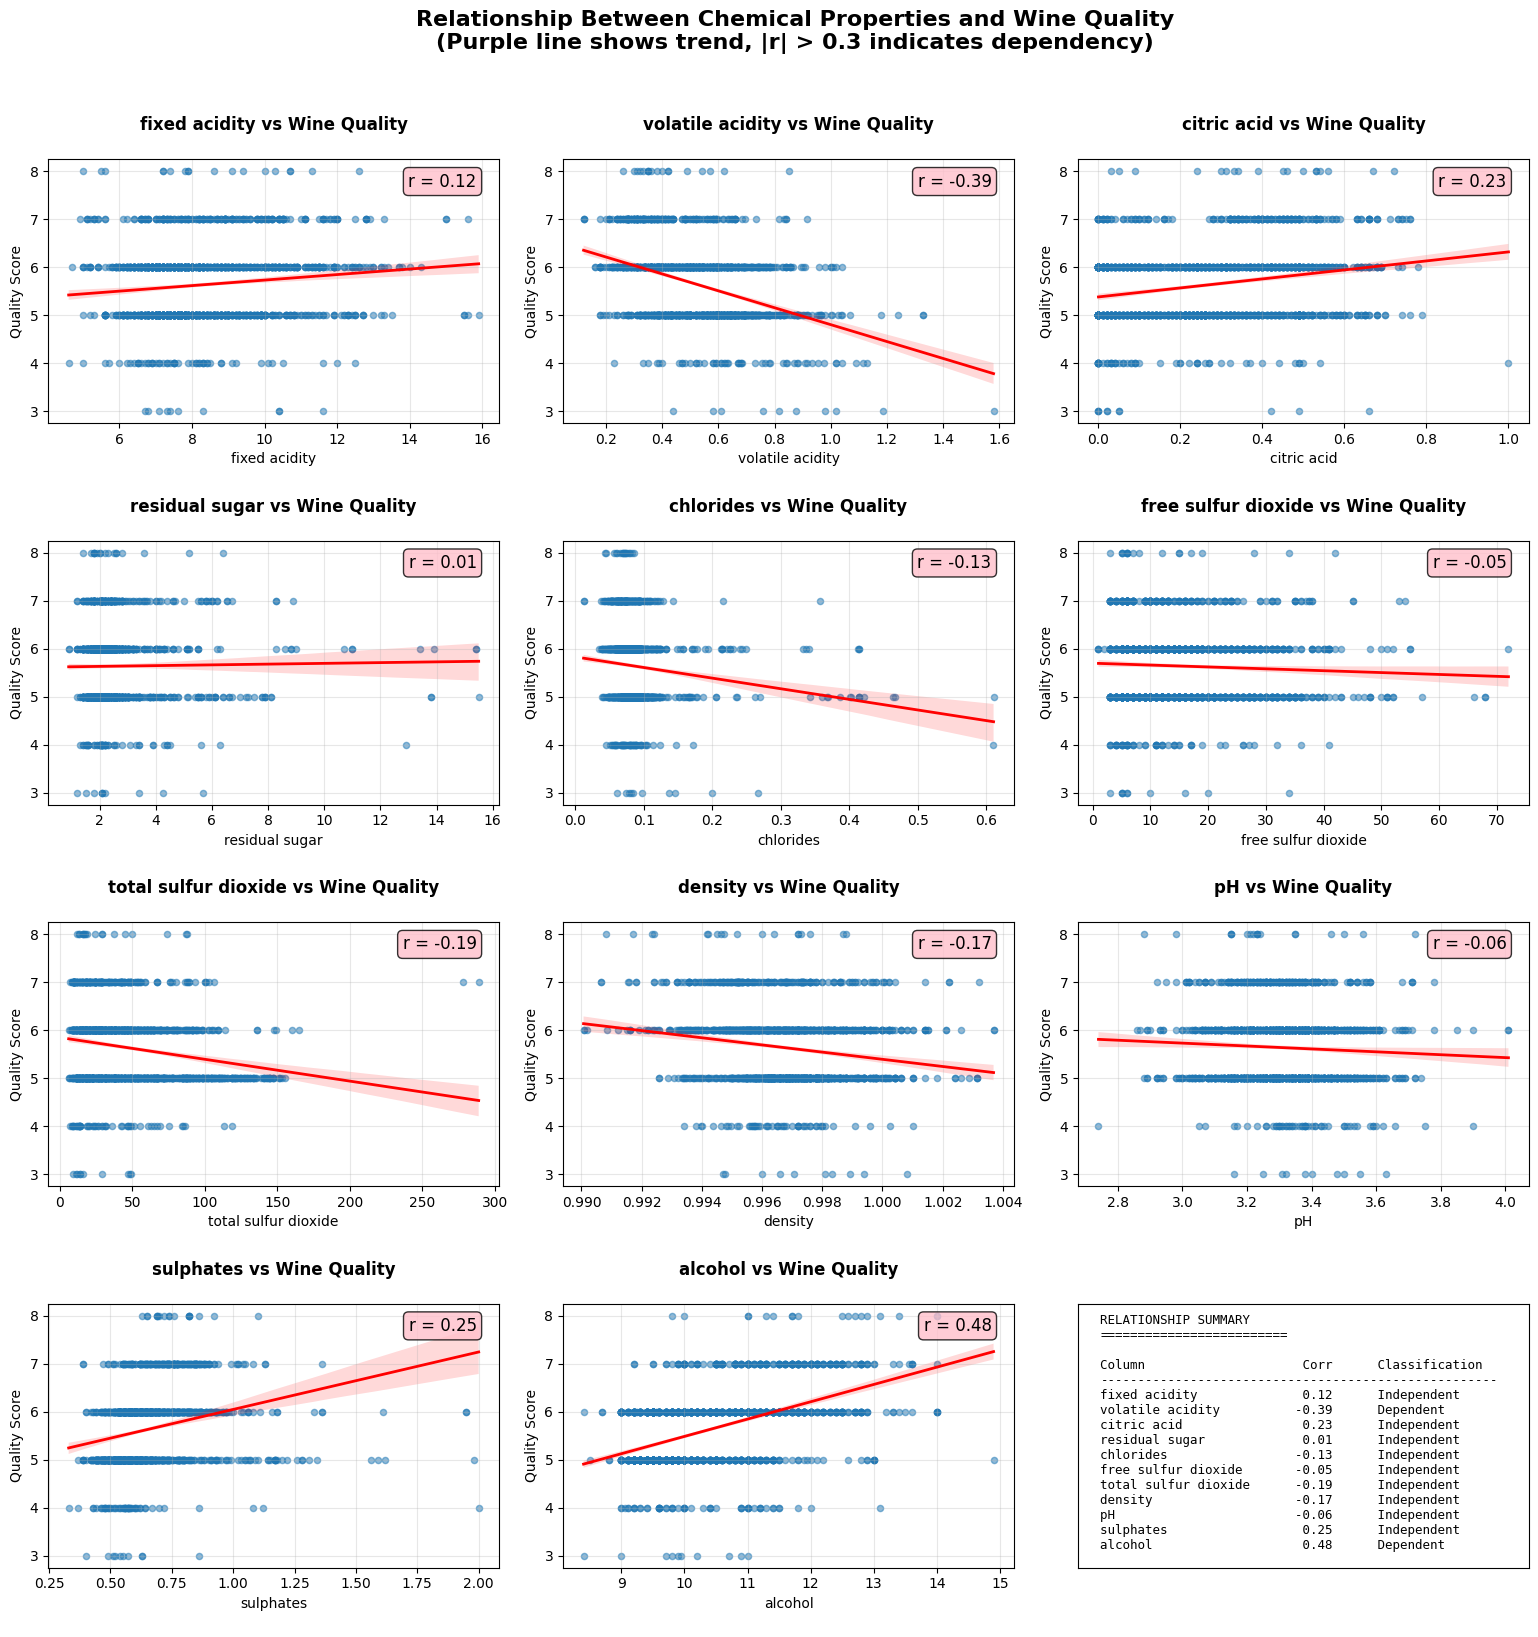

In [202]:
# Get all input columns.
input_columns = [col for col in redwine.columns if col != 'target']

# Create subplots
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

# Store relationship analysis
relationships = {}

for idx, col in enumerate(input_columns):
    ax = axes[idx]
    
    # Scatter plot with trend line
    sns.regplot(data=redwine, x=col, y='target', ax=ax, 
                scatter_kws={'alpha': 0.5, 's': 20},
                line_kws={'color': 'red', 'linewidth': 2})
    
    # Calculate correlation 
    correlation = redwine[col].corr(redwine['target'])
    
    # Determine relationship type
    # Based on standard statistical references, 
    # the 0.3 value is the threshold for a "medium" 
    # or "moderate" effect size for a correlation
    #
    # https://lsr-wiki-02.mrc-cbu.cam.ac.uk/statswiki/FAQ/effectSize?action=Load&rev=61
    
    if abs(correlation) > 0.3:
        relationship = "Dependent"

    else:
        relationship = "Independent"
    
    relationships[col] = {
        'correlation': correlation,
        'relationship': relationship
    }
    
    # Add correlation text. The "target" = Wine Quality
    ax.text(0.95, 0.95, f'r = {correlation:.2f}', transform=ax.transAxes,
        fontsize=12, horizontalalignment='right', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='pink', alpha=0.8))
    
    ax.set_title(f'{col} vs Wine Quality\n', fontsize=12, fontweight='bold')
    ax.set_xlabel(col+'\n', fontsize=10)
    ax.set_ylabel('Quality Score', fontsize=10)
    ax.grid(True, alpha=0.3)

# Use the 12th subplot for summary text
axes[11].set_visible(True)
axes[11].grid(False)
axes[11].set_xlabel('')
axes[11].set_ylabel('')
axes[11].set_xticks([])
axes[11].set_yticks([])

# Build summary text
summary_text = "RELATIONSHIP SUMMARY\n"
summary_text += "=" * 25 + "\n\n"
summary_text += f"{'Column':<22} {'Corr':>8}      {'Classification':<12}\n"
summary_text += "-" * 53 + "\n"

for col, info in relationships.items():
    summary_text += f"{col[:22]:<22} {info['correlation']:>8.2f}      {info['relationship']:<12}\n"

# Add text to subplot
axes[11].text(0.05, 0.96, summary_text, transform=axes[11].transAxes,
              fontsize=9, verticalalignment='top', fontfamily='monospace')

plt.suptitle('Relationship Between Chemical Properties and Wine Quality\n'
             '(Purple line shows trend, |r| > 0.3 indicates dependency)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

#### Wine Quality Correlationship Analysis

| Column | Correlation | Classification | Why |
|--------|-------------|----------------|-----|
| fixed acidity | +0.12 | Independent | Not strongly related to quality |
| volatile acidity | -0.39 | Dependent (Negative) | Vinegar-like taste reduces quality |
| citric acid | +0.23 | Independent (Weak positive) | Some positive effect on freshness |
| residual sugar | +0.01 | Independent | Sweetness doesn't strongly affect red wine quality |
| chlorides | -0.13 | Independent | Salt content minimal impact |
| free sulfur dioxide | -0.05 | Independent | Preservative levels not strongly related |
| total sulfur dioxide | -0.04 | Independent | Preservative levels not strongly related |
| density | -0.17 | Independent | Inverse weak relationship with alcohol |
| pH | -0.06 | Independent | Acidity (pH) not strongly predictive alone |
| sulphates | +0.25 | Independent (Weak positive) | Slight positive effect, but not strong |
| alcohol | +0.48 | Dependent (Positive) | Higher alcohol wines are generally rated higher quality |

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the mean squared error of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

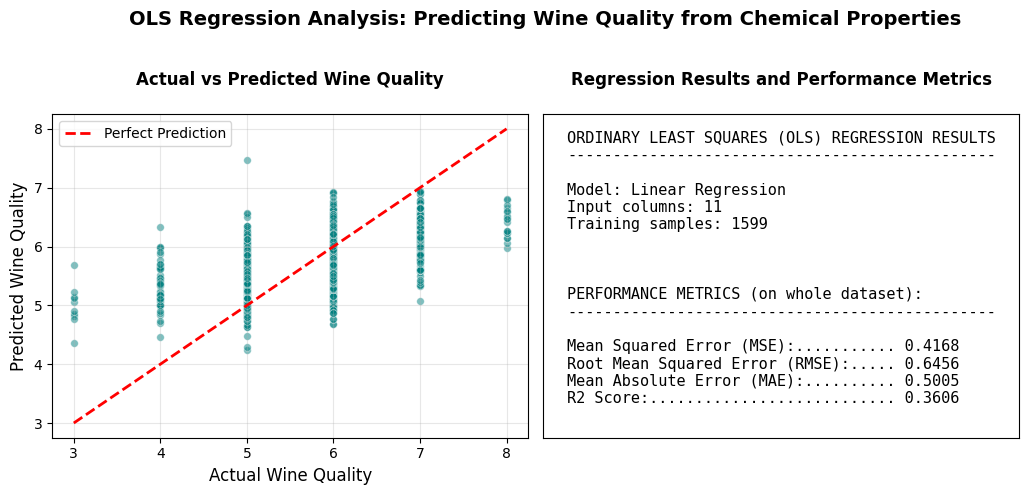

In [203]:
# PROBLEM 5: BUILD OLS REGRESSION ON ALL FEATURES

# Prepare data
X = redwine.drop('target', axis=1)
y = redwine['target']

# Build Ordinary Least Squares regression model
model = LinearRegression()
model.fit(X, y)

# Make predictions on the whole dataset
y_pred_p5 = model.predict(X)

# Calculate metrics
p5_mse = mean_squared_error(y, y_pred_p5)
p5_rmse = np.sqrt(p5_mse)
p5_mae = mean_absolute_error(y, y_pred_p5)
p5_r2 = r2_score(y, y_pred_p5)

# Create figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Use the Left subplot for Scatter plot
ax1.scatter(y, y_pred_p5, alpha=0.5, s=30, color='teal', edgecolor='white', linewidth=0.5)

# Perfect prediction line
min_val = min(y.min(), y_pred_p5.min())
max_val = max(y.max(), y_pred_p5.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax1.set_xlabel('Actual Wine Quality', fontsize=12)
ax1.set_ylabel('Predicted Wine Quality', fontsize=12)
ax1.set_title('Actual vs Predicted Wine Quality\n', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Use the Right subplot for summary text
ax2.set_visible(True)
ax2.grid(False)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title('Regression Results and Performance Metrics\n', fontsize=12, fontweight='bold')

# Build metrics text
metrics_text = "ORDINARY LEAST SQUARES (OLS) REGRESSION RESULTS\n"
metrics_text += "-" * 47 + "\n\n"
metrics_text += f"Model: Linear Regression\n"
metrics_text += f"Input columns: {X.shape[1]}\n"
metrics_text += f"Training samples: {X.shape[0]}\n\n\n\n"
metrics_text += "PERFORMANCE METRICS (on whole dataset):\n"
metrics_text += "-" * 47 + "\n\n"
metrics_text += f"Mean Squared Error (MSE):........... {p5_mse:.4f}\n"
metrics_text += f"Root Mean Squared Error (RMSE):..... {p5_rmse:.4f}\n"
metrics_text += f"Mean Absolute Error (MAE):.......... {p5_mae:.4f}\n"
metrics_text += f"R2 Score:........................... {p5_r2:.4f}\n\n"

# Add text to subplot
ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace')

# Main title for the entire figure
fig.suptitle('OLS Regression Analysis: Predicting Wine Quality from Chemical Properties\n', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


In [204]:
# PROBLEM 6: PART 1 - BEST SINGLE FEATURE FOR PREDICTING WINE QUALITY

# Prepare data
X = redwine.drop('target', axis=1)
y = redwine['target']

# Store results for single-feature models
single_feature_results = {}

# Test each input column individually
for col in X.columns:
    
    # Train and predict model on single feature
    model = LinearRegression()
    model.fit(X[[col]], y)
    y_pred_p6 = model.predict(X[[col]])
    
    # Calculate metrics
    p6_mse = mean_squared_error(y, y_pred_p6)
    p6_rmse = np.sqrt(p6_mse)
    p6_mae = mean_absolute_error(y, y_pred_p6)
    p6_r2 = r2_score(y, y_pred_p6)
    
    # Store results for each column
    single_feature_results[col] = {
        'mse': p6_mse,
        'rmse': p6_rmse,
        'mae': p6_mae,
        'r2': p6_r2
    }

# Find best single feature (lowest MSE)
best_feature = min(single_feature_results.items(), key=lambda x: x[1]['mse'])
best_feature_name = best_feature[0]
best_feature_metrics = best_feature[1]

# Print comparison results
print("PROBLEM 6: PART 1 - BEST SINGLE FEATURE FOR PREDICTING WINE QUALITY")
print("-" * 70)
print(f"\nBEST SINGLE FEATURE: {best_feature_name}")
print(f"   MSE: {best_feature_metrics['mse']:.4f}")
print(f"  RMSE: {best_feature_metrics['rmse']:.4f}")
print(f"   MAE: {best_feature_metrics['mae']:.4f}")
print(f"    R2: {best_feature_metrics['r2']:.4f}")

PROBLEM 6: PART 1 - BEST SINGLE FEATURE FOR PREDICTING WINE QUALITY
----------------------------------------------------------------------

BEST SINGLE FEATURE: alcohol
   MSE: 0.5040
  RMSE: 0.7099
   MAE: 0.5621
    R2: 0.2267


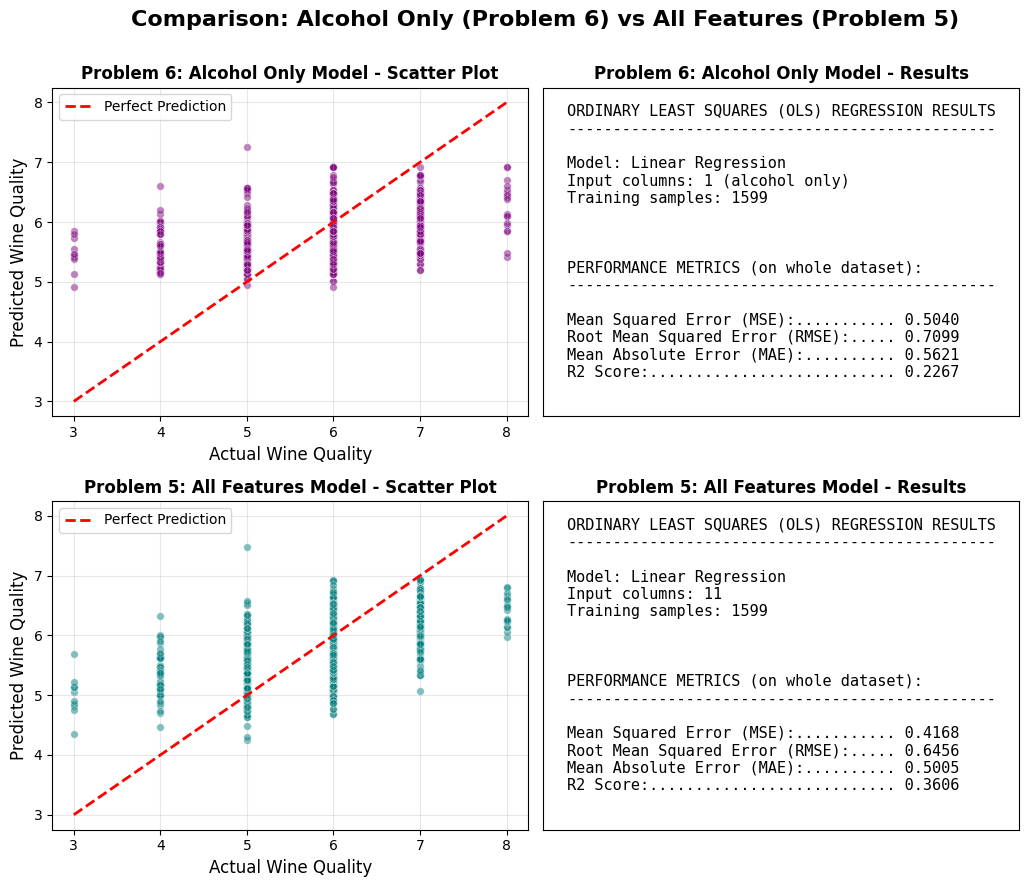

In [205]:
# PROBLEM 6: PART 2 - COMPARISON

# Create comparison plot with 4 subplots
fig = plt.figure(figsize=(11, 9))

# Top Left: Problem 6 scatter plot
ax1 = plt.subplot(2, 2, 1)
ax1.scatter(y, y_pred_p6, alpha=0.5, s=30, color='purple', edgecolor='white', linewidth=0.5)

# Perfect prediction line
min_val = min(y.min(), y_pred_p6.min())
max_val = max(y.max(), y_pred_p6.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax1.set_xlabel('Actual Wine Quality', fontsize=12)
ax1.set_ylabel('Predicted Wine Quality', fontsize=12)
ax1.set_title('Problem 6: Alcohol Only Model - Scatter Plot', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Top Right: Problem 6 results text
ax2 = plt.subplot(2, 2, 2)
ax2.set_visible(True)
ax2.grid(False)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title('Problem 6: Alcohol Only Model - Results', fontsize=12, fontweight='bold')

# Build metrics text for Alcohol model
metrics_text_alcohol = "ORDINARY LEAST SQUARES (OLS) REGRESSION RESULTS\n"
metrics_text_alcohol += "-" * 47 + "\n\n"
metrics_text_alcohol += f"Model: Linear Regression\n"
metrics_text_alcohol += f"Input columns: 1 (alcohol only)\n"
metrics_text_alcohol += f"Training samples: {X.shape[0]}\n\n\n\n"
metrics_text_alcohol += "PERFORMANCE METRICS (on whole dataset):\n"
metrics_text_alcohol += "-" * 47 + "\n\n"
metrics_text_alcohol += f"Mean Squared Error (MSE):........... {p6_mse:.4f}\n"
metrics_text_alcohol += f"Root Mean Squared Error (RMSE):..... {p6_rmse:.4f}\n"
metrics_text_alcohol += f"Mean Absolute Error (MAE):.......... {p6_mae:.4f}\n"
metrics_text_alcohol += f"R2 Score:........................... {p6_r2:.4f}\n\n"

ax2.text(0.05, 0.95, metrics_text_alcohol, transform=ax2.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace')

# Bottom Left: Problem 5 scatter plot
ax3 = plt.subplot(2, 2, 3)
ax3.scatter(y, y_pred_p5, alpha=0.5, s=30, color='teal', edgecolor='white', linewidth=0.5)

# Perfect prediction line
min_val = min(y.min(), y_pred_p5.min())
max_val = max(y.max(), y_pred_p5.max())
ax3.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax3.set_xlabel('Actual Wine Quality', fontsize=12)
ax3.set_ylabel('Predicted Wine Quality', fontsize=12)
ax3.set_title('Problem 5: All Features Model - Scatter Plot', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Bottom Right: Problem 5 results text
ax4 = plt.subplot(2, 2, 4)
ax4.set_visible(True)
ax4.grid(False)
ax4.set_xlabel('')
ax4.set_ylabel('')
ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Problem 5: All Features Model - Results', fontsize=12, fontweight='bold')

# Build metrics text for Full model
metrics_text_full = "ORDINARY LEAST SQUARES (OLS) REGRESSION RESULTS\n"
metrics_text_full += "-" * 47 + "\n\n"
metrics_text_full += f"Model: Linear Regression\n"
metrics_text_full += f"Input columns: {X.shape[1]}\n"
metrics_text_full += f"Training samples: {X.shape[0]}\n\n\n\n"
metrics_text_full += "PERFORMANCE METRICS (on whole dataset):\n"
metrics_text_full += "-" * 47 + "\n\n"
metrics_text_full += f"Mean Squared Error (MSE):........... {p5_mse:.4f}\n"
metrics_text_full += f"Root Mean Squared Error (RMSE):..... {p5_rmse:.4f}\n"
metrics_text_full += f"Mean Absolute Error (MAE):.......... {p5_mae:.4f}\n"
metrics_text_full += f"R2 Score:........................... {p5_r2:.4f}\n\n"

ax4.text(0.05, 0.95, metrics_text_full, transform=ax4.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace')

# Main title for the entire figure
fig.suptitle('Comparison: Alcohol Only (Problem 6) vs All Features (Problem 5)\n', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

#### Model Performance Comparison

| Metric | Problem 6 (Alcohol Only) | Problem 5 (All Features) |
|:-------|:------------------------:|:-------------------------:|
| **MSE**  | 0.5040 | 0.4168 |
| **RMSE** | 0.7099 | 0.6456 |
| **MAE**  | 0.5621 | 0.5005 |
| **R2**   | 0.2267 | 0.3606 |
| **Features** | 1 | 11 |

As the results showed, the full model reduces MSE by **17.3%** (from 0.5040 to 0.4168) and increases R2 by **59.0%** (from 0.2267 to 0.3606). The model using all 11 chemical features (Problem 5) performs better than using just alcohol alone (Problem 6). It shows that wine quality depends on multiple interacting chemical properties, not just alcohol content.

### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

Selected threshold for alcohol: 10.20
Low alcohol group: 796 samples
High alcohol group: 803 samples


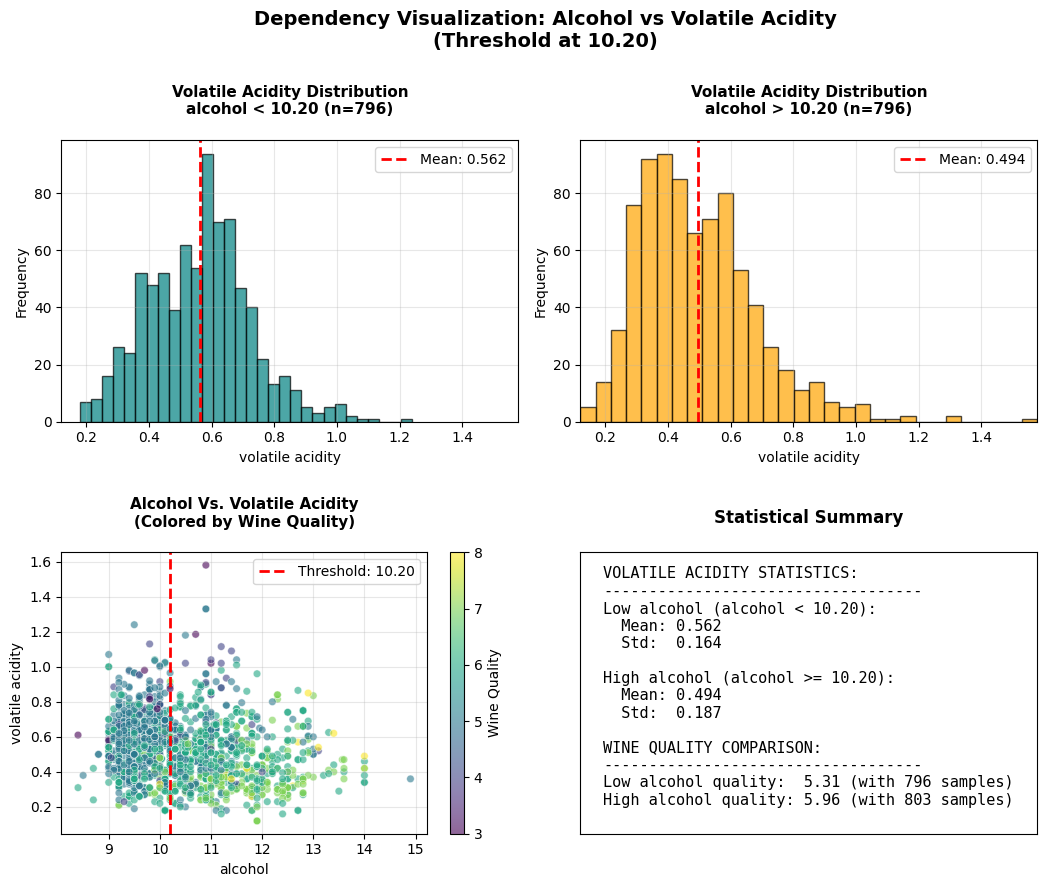

In [206]:
# Prom Problem 4, I'll pick Alcohol and Volatile Acidity, since they have visible dependencies with wine quality

# Prepare data
col1 = 'alcohol'
col2 = 'volatile acidity'

# Choose a threshold for alcohol: Median
threshold = redwine[col1].median()

# Create two subsets
low_alcohol = redwine[redwine[col1] < threshold]
high_alcohol = redwine[redwine[col1] >= threshold]

print(f"Selected threshold for {col1}: {threshold:.2f}")
print(f"Low alcohol group: {len(low_alcohol)} samples")
print(f"High alcohol group: {len(high_alcohol)} samples")

# Create 2x2 subplots
fig = plt.figure(figsize=(11, 9))

# Top Left: Histogram of volatile acidity for LOW alcohol
ax1 = plt.subplot(2,2,1) 
ax1.hist(low_alcohol[col2], bins=30, alpha=0.7, color='teal', edgecolor='black')
ax1.axvline(low_alcohol[col2].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {low_alcohol[col2].mean():.3f}')
ax1.set_xlabel(col2)
ax1.set_ylabel('Frequency')
ax1.set_title(f'Volatile Acidity Distribution\n{col1} < {threshold:.2f} (n={len(low_alcohol)})\n', 
              fontsize=11, fontweight='bold')
ax1.set_xlim(redwine[col2].min(), redwine[col2].max())
ax1.legend()
ax1.grid(True, alpha=0.3)


# Top Right: Histogram of volatile acidity for HIGH alcohol
ax2 = plt.subplot(2,2,2) 
ax2.hist(high_alcohol[col2], bins=30, alpha=0.7, color='orange', edgecolor='black')
ax2.axvline(high_alcohol[col2].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {high_alcohol[col2].mean():.3f}')
ax2.set_xlabel(col2)
ax2.set_ylabel('Frequency')
ax2.set_title(f'Volatile Acidity Distribution\n{col1} > {threshold:.2f} (n={len(low_alcohol)})\n', 
              fontsize=11, fontweight='bold')
ax2.set_xlim(redwine[col2].min(), redwine[col2].max())
ax2.legend()
ax2.grid(True, alpha=0.3)


# Bottom Left: Scatter plot (Alcohol vs Volatile Acidity)
ax3 = plt.subplot(2,2,3) 
scatter = ax3.scatter(redwine[col1], redwine[col2], 
                      c=redwine['target'], cmap='viridis', 
                      alpha=0.6, s=30, edgecolor='white', linewidth=0.5)
ax3.set_xlabel(col1)
ax3.set_ylabel(col2)
ax3.set_title('\nAlcohol Vs. Volatile Acidity\n(Colored by Wine Quality)\n', fontsize=11, fontweight='bold')
ax3.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold: {threshold:.2f}')
plt.colorbar(scatter, ax=ax3, label='Wine Quality')
ax3.legend()
ax3.grid(True, alpha=0.3)


# Bottom Right: Statistical Summary
ax4 = plt.subplot(2,2,4) 
ax4.set_visible(True)
ax4.grid(False)
ax4.set_xlabel('')
ax4.set_ylabel('')
ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Statistical Summary\n', fontsize=12, fontweight='bold')

# Build statistical summary text
stats_text = f"{col2.upper()} STATISTICS:\n"
stats_text += "-" * 35 + "\n"
stats_text += f"Low alcohol ({col1} < {threshold:.2f}):\n"
stats_text += f"  Mean: {low_alcohol[col2].mean():.3f}\n"
stats_text += f"  Std:  {low_alcohol[col2].std():.3f}\n\n"
stats_text += f"High alcohol ({col1} >= {threshold:.2f}):\n"
stats_text += f"  Mean: {high_alcohol[col2].mean():.3f}\n"
stats_text += f"  Std:  {high_alcohol[col2].std():.3f}\n\n"
stats_text += "WINE QUALITY COMPARISON:\n"
stats_text += "-" * 35 + "\n"
stats_text += f"Low alcohol quality:  {low_alcohol['target'].mean():.2f} (with {len(low_alcohol)} samples)\n"
stats_text += f"High alcohol quality: {high_alcohol['target'].mean():.2f} (with {len(high_alcohol)} samples)\n\n"

ax4.text(0.05, 0.95, stats_text, transform=ax4.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace')

# Main title for the entire figure
fig.suptitle(f'Dependency Visualization: Alcohol vs Volatile Acidity\n(Threshold at {threshold:.2f})\n', 
             fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the mean squared error of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

Total input columns: 11
Using first 5 principal components (half of 11)
Variance explained by first 5 components: 79.53%


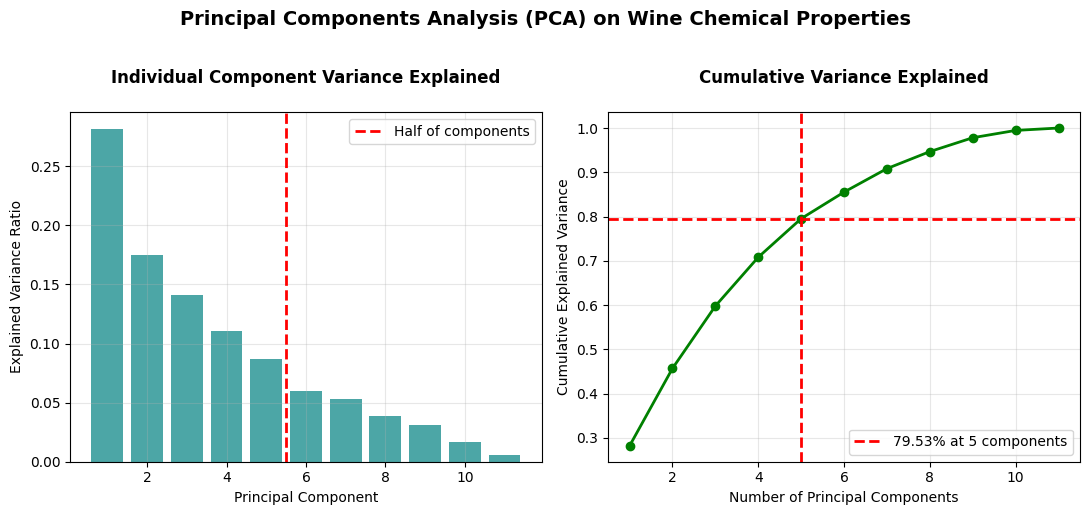

In [207]:
# This was covered in DX699 class

# Prepare data
X = redwine.drop('target', axis=1)
y = redwine['target']

# Standardize the data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Number of components for first half
n_components = X.shape[1] // 2  # First half of components
print(f"Total input columns: {X.shape[1]}")
print(f"Using first {n_components} principal components (half of {X.shape[1]})")

# Calculate variance explained by first half
variance_explained = cumulative_variance[n_components - 1] * 100
print(f"Variance explained by first {n_components} components: {variance_explained:.2f}%")

# Create visualization of explained variance
fig = plt.figure(figsize=(11, 5))

# Plot 1: Individual explained variance
ax1 = plt.subplot(1,2,1)
ax1.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='teal')
ax1.axvline(x=n_components + 0.5, color='red', linestyle='--', linewidth=2, label='Half of components')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Component Variance Explained\n', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative explained variance
ax2 = plt.subplot(1,2,2)
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o-', linewidth=2, markersize=6, color='green')
ax2.axhline(y=cumulative_variance[n_components - 1], color='red', linestyle='--', 
            linewidth=2, label=f'{variance_explained:.2f}% at {n_components} components')
ax2.axvline(x=n_components, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance Explained\n', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Principal Components Analysis (PCA) on Wine Chemical Properties', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

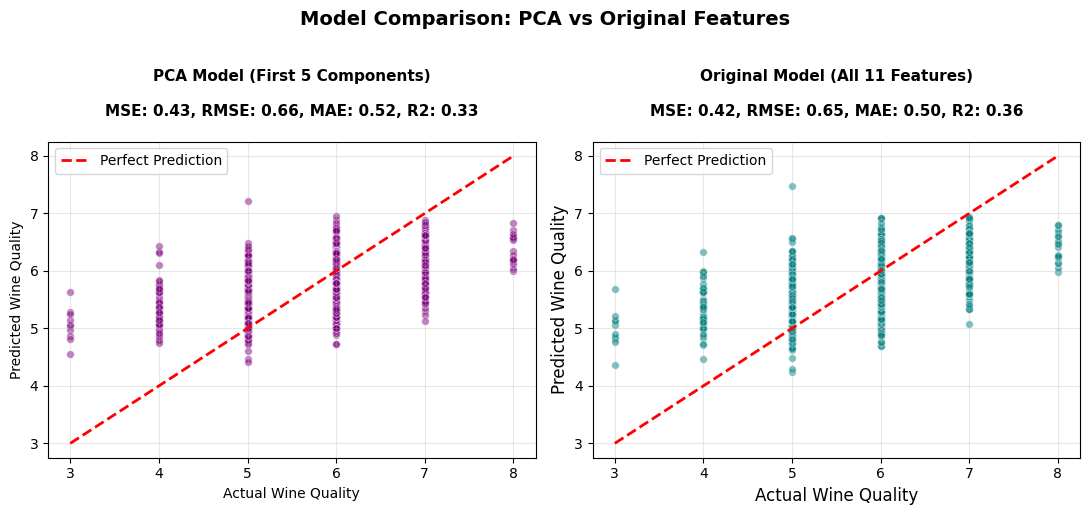

In [208]:
# Build regression model using first half of principal components
X_pca_first_half = X_pca[:, :n_components]

pca_model = LinearRegression()
pca_model.fit(X_pca_first_half, y)
y_pred_pca = pca_model.predict(X_pca_first_half)

# Calculate metrics for PCA model
pca_mse = mean_squared_error(y, y_pred_pca)
pca_rmse = np.sqrt(pca_mse)
pca_mae = mean_absolute_error(y, y_pred_pca)
pca_r2 = r2_score(y, y_pred_pca)

# Using calulated model metrics (from Problem 5, full set)
p5_mse = 0.4168
p5_rmse = 0.6456
p5_mae = 0.5005
p5_r2 = 0.3606

# Create comparison plots
fig = plt.figure(figsize=(11, 5))

# Left: PCA model predictions
ax1 = plt.subplot(1,2,1)
ax1.scatter(y, y_pred_pca, alpha=0.5, s=30, color='purple', edgecolor='white', linewidth=0.5)
min_val = min(y.min(), y_pred_pca.min())
max_val = max(y.max(), y_pred_pca.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Wine Quality')
ax1.set_ylabel('Predicted Wine Quality')
ax1.set_title(f'PCA Model (First 5 Components)\n\nMSE: {pca_mse:.2f}, RMSE: {pca_rmse:.2f}, MAE: {pca_mae:.2f}, R2: {pca_r2:.2f}\n', 
              fontsize=11, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Previous model (Problem 5) predictions
ax2 = plt.subplot(1,2,2)
ax2.scatter(y, y_pred_p5, alpha=0.5, s=30, color='teal', edgecolor='white', linewidth=0.5)
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Wine Quality', fontsize=12)
ax2.set_ylabel('Predicted Wine Quality', fontsize=12)
ax2.set_title(f'Original Model (All 11 Features)\n\nMSE: {p5_mse:.2f}, RMSE: {p5_rmse:.2f}, MAE: {p5_mae:.2f}, R2: {p5_r2:.2f}\n', 
              fontsize=11, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Model Comparison: PCA vs Original Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Model Performance Comparison

| Metric | Problem 8 (PCA - First 5 Features) | Problem 5 (All 11 Features) |
|:-------|:------------------------:|:-------------------------:|
| **MSE**  | 0.4344 | 0.4168 |
| **RMSE** | 0.6591 | 0.6456 |
| **MAE**  | 0.5163 | 0.5005 |
| **R2**   | 0.3335 | 0.3606 |
| **Features** | 5 | 11 |

As the results showed, variance explained by first 5 components is 79.53%. The PCA model MSE increased by **4.2%** (from 0.4168 to 0.4344) compared to the original model. It also decreased R2 by **7.5%** (from 0.3606 to 0.3335). The PCA model using first 5 chemical features (Problem 8) performs worse than using all 11 original features (Problem 5). It shows that the reduction in dimensionality didn't provide better predictive since it also discarded some  valuable information for predicting wine quality.

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

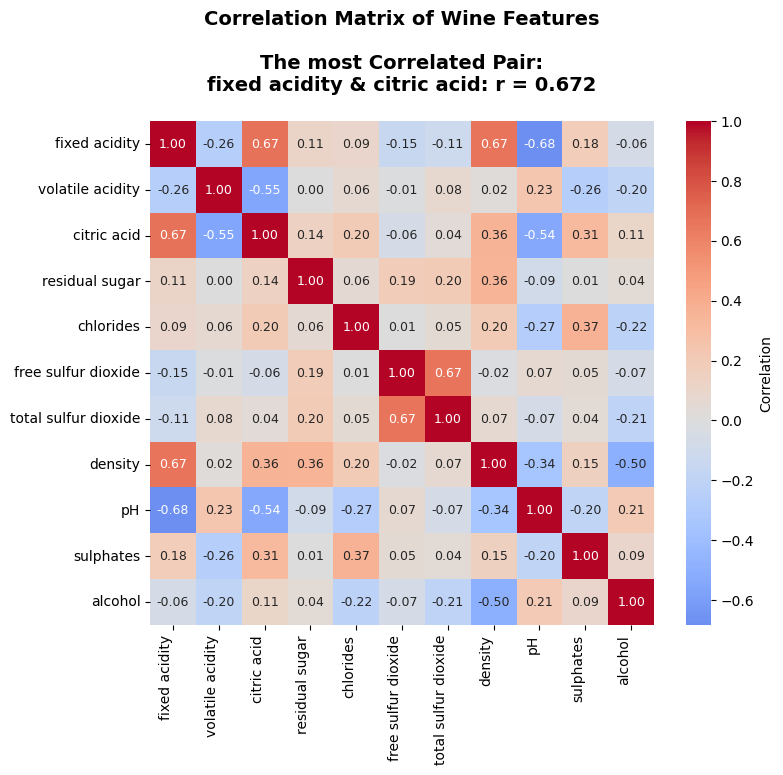

In [209]:
# Prepare data
X = redwine.drop('target', axis=1)

# Find the most correlated pairs
correlated_pairs = X.corr().unstack().sort_values(ascending=False)

# Filter out same-column correlations
most_correlated = correlated_pairs[(correlated_pairs < 0.999) & (correlated_pairs != 1.0)]

# Get the highest correlation pair (first one)
highest_pair = most_correlated.index[0]
highest_value = most_correlated.iloc[0]

# Create title with the most correlated pair
title_text = f'Correlation Matrix of Wine Features\n\nThe most Correlated Pair:\n{highest_pair[0]} & {highest_pair[1]}: r = {highest_value:.3f}\n'

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.79, 'label': 'Correlation'})
plt.title(title_text, fontsize=14, fontweight='bold')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

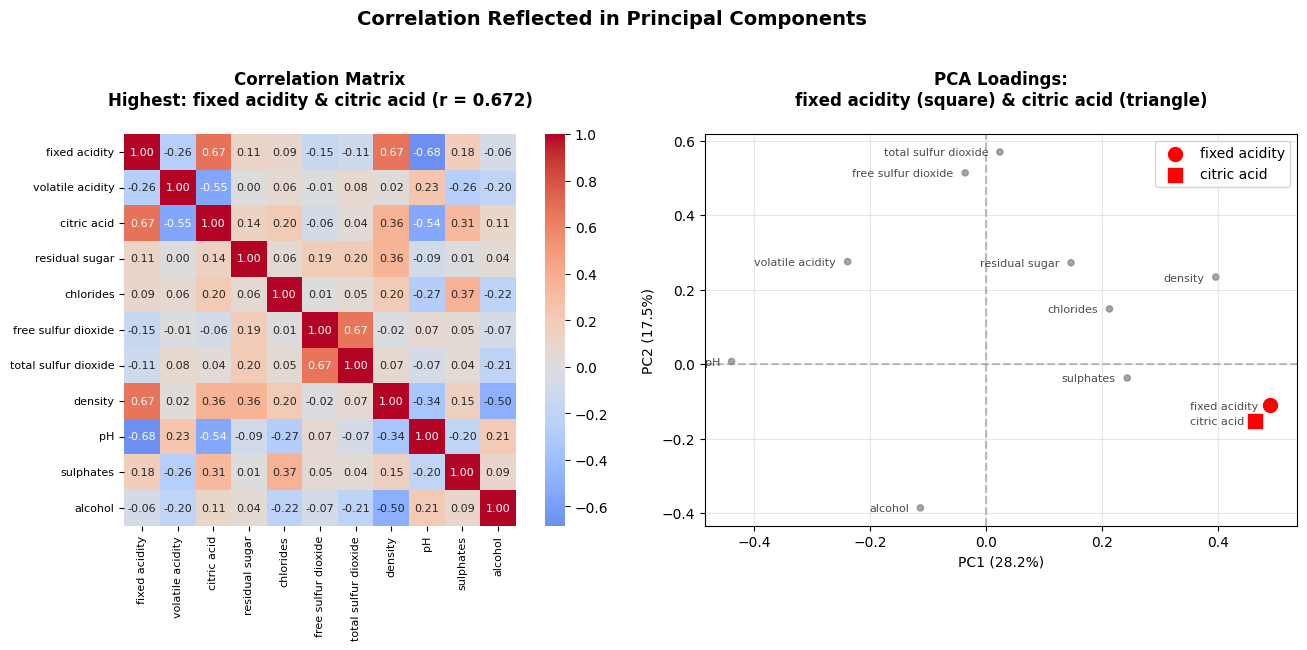

In [ ]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Get the pair
col1, col2 = most_correlated.index[0]  

# LEFT: Heatmap above
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, ax=ax1, annot_kws={'size': 8})
ax1.set_title(f'Correlation Matrix\nHighest: {col1} & {col2} (r = {highest_value:.3f})\n', 
              fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=90, labelsize=8)
ax1.tick_params(axis='y', labelsize=8)

# RIGHT: PCA loadings for 2 most correlated features
components = [f'PC{i+1}' for i in range(5)]
loadings = pd.DataFrame(pca.components_[:5].T, 
                        columns=components, 
                        index=X.columns)

# Highlight the correlated pair
sizes = [60 if (feature == col1 or feature == col2) else 20 
         for feature in X.columns]

# Scatter plot of PC1 vs PC2 loadings
ax2.scatter(loadings['PC1'], loadings['PC2'], c='gray', s=sizes, alpha=0.7)

# Add labels for all points
for feature in X.columns:
    ax2.annotate(feature, (loadings.loc[feature, 'PC1']- 0.02, loadings.loc[feature, 'PC2']-0.01),
                fontsize=8, alpha=0.7, horizontalalignment='right')
    
# Highlight the correlated pair
ax2.scatter(loadings.loc[col1, 'PC1'], loadings.loc[col1, 'PC2'], 
            c='red',s=100, marker='o', label=col1)

ax2.scatter(loadings.loc[col2, 'PC1'], loadings.loc[col2, 'PC2'], 
            c='red', s=100, marker='s', label=col2)

ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_title(f'PCA Loadings:\n{col1} (square) & {col2} (triangle)\n', 
              fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Correlation Reflected in Principal Components', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### How is that correlation reflected in the principal components?

The high correlation between `fixed acidity` and `citric acid` **(r = 0.67)** is reflected in the PCA loadings plot. In that plot, these two features are positioned close together, indicating they contribute similarly to the principal components. PCA works by finding directions of maximum variance, and highly correlated features should move together in these directions. Both features have strong positive PC1 loading.

### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria discussed in this module, and you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

In [349]:
# Calculate Z-scores for ALL columns
z_scores = (redwine - redwine.mean()) / redwine.std()

# Count total of |z-score| > 3 (more than 3 std is considered outlier)
extreme_counts = (z_scores.abs() > 3).sum(axis=1)

# Find the extreme outlier index (max)
outlier_idx = extreme_counts.idxmax()

# Find that row using the index above
outlier_row = redwine.loc[outlier_idx]

# Get the z-scores for the outlier row
outlier_z_scores = z_scores.loc[outlier_idx]

# Find which features have |z| > 3
extreme_features = outlier_z_scores[outlier_z_scores.abs() > 3]

print("=" * 58)
print(f"OUTLIER ROW ANALYSIS: Index # {outlier_idx}")
print("=" * 58)

# Print header
print(f"\n{'Feature':<20} {'Actual Value':<15} {'Z-Score':<11} {'Extreme?':<10}")
print("-" * 58)

# Print each feature with its z-score and extreme status
for col in redwine.columns:
    actual = outlier_row[col]
    z = outlier_z_scores[col]
    extreme = "YES" if abs(z) > 3 else "NO"
    
    # Add visual indicator for extreme values
    if abs(z) > 3:
        print(f"{col:<20} {actual:>12.2f} {z:>+10.2f} {extreme:>8}")
    else:
        print(f"{col:<20} {actual:>12.2f} {z:>+10.2f} {extreme:>8}")

print("-" * 58)
print(f"\nThis row index # {outlier_idx} has {extreme_counts[outlier_idx]} features with |z-score| > 3")
print(f"Out of {len(redwine)} total rows, this row has the most extreme outliers.")
print(f"\nExtreme features: {', '.join(list(extreme_features.index))}")

OUTLIER ROW ANALYSIS: Index # 151

Feature              Actual Value    Z-Score     Extreme?  
----------------------------------------------------------
fixed acidity                9.20      +0.51       NO
volatile acidity             0.52      -0.04       NO
citric acid                  1.00      +3.74      YES
residual sugar               3.40      +0.61       NO
chlorides                    0.61     +11.10      YES
free sulfur dioxide         32.00      +1.54       NO
total sulfur dioxide        69.00      +0.68       NO
density                      1.00      +1.51       NO
pH                           2.74      -3.70      YES
sulphates                    2.00      +7.92      YES
alcohol                      9.40      -0.96       NO
target                       4.00      -2.03       NO
----------------------------------------------------------

This row index # 151 has 4 features with |z-score| > 3
Out of 1599 total rows, this row has the most extreme outliers.

Extreme features: 

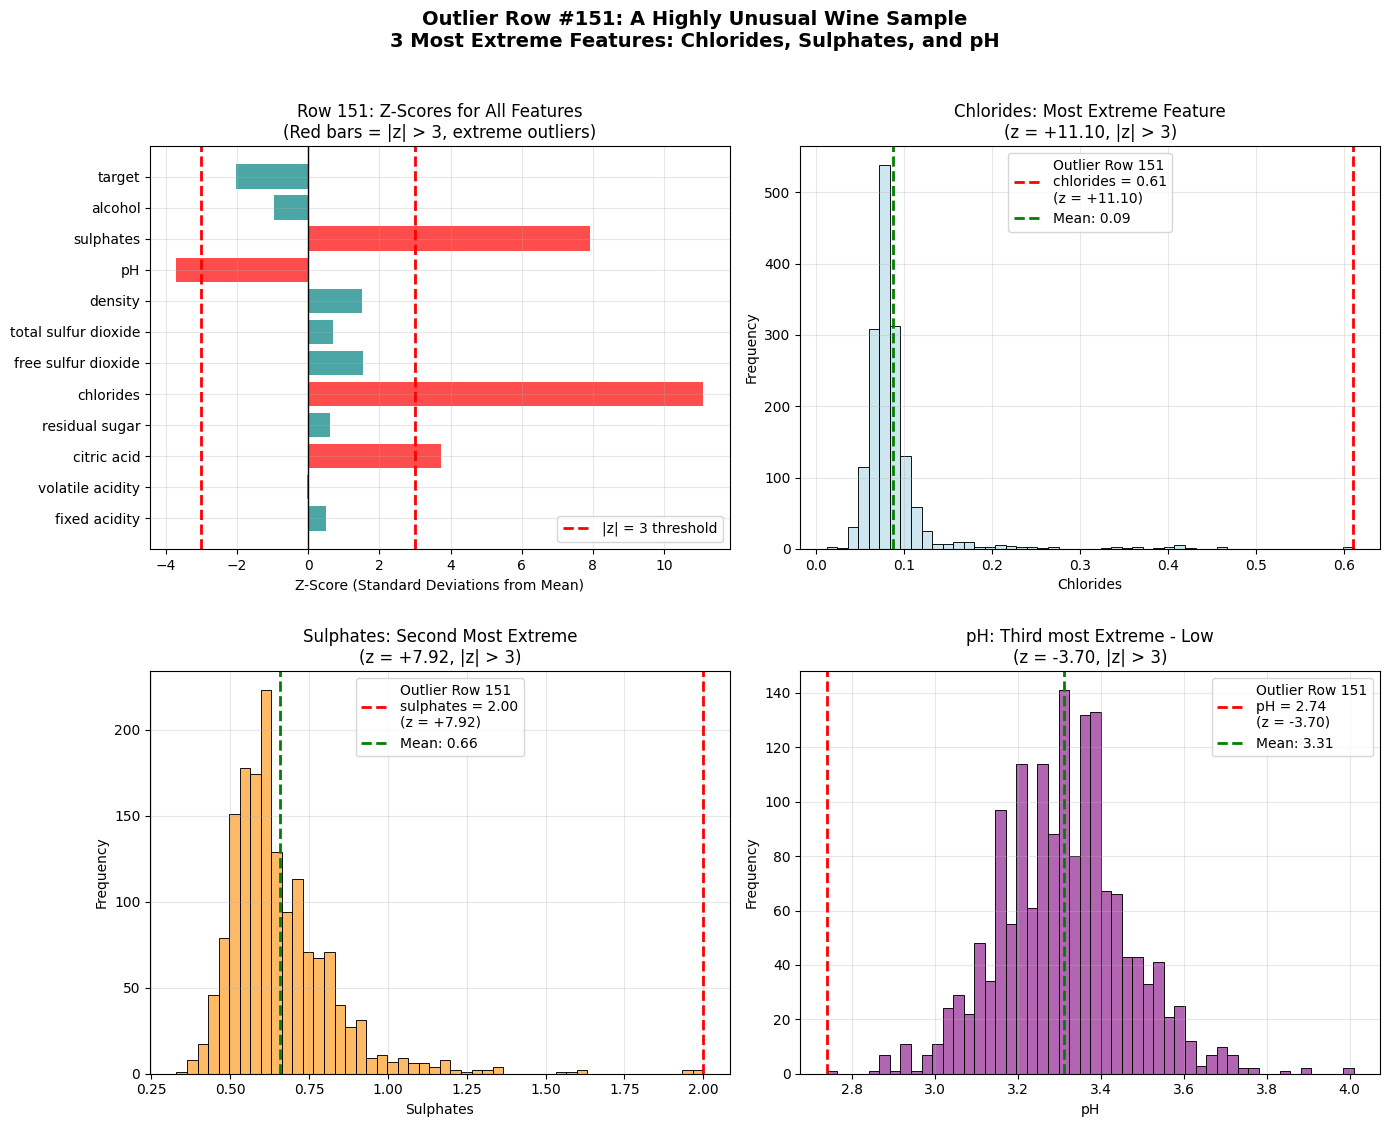

In [321]:
# Create visualizations with 4 subplots
fig = plt.figure(figsize=(14, 11))

# Plot 1: Z-scores bar chart for all features
ax1 = plt.subplot(2,2,1)
colors = ['red' if abs(z) > 3 else 'teal' for z in outlier_z_scores]
bars = ax1.barh(range(len(outlier_z_scores)), outlier_z_scores.values, color=colors, alpha=0.7)
ax1.set_yticks(range(len(outlier_z_scores)))
ax1.set_yticklabels(outlier_z_scores.index)
ax1.axvline(x=3, color='red', linestyle='--', linewidth=2, label='|z| = 3 threshold')
ax1.axvline(x=-3, color='red', linestyle='--', linewidth=2)
ax1.axvline(x=0, color='black', linewidth=1)
ax1.set_xlabel('Z-Score (Standard Deviations from Mean)')
ax1.set_title(f'Row {outlier_idx}: Z-Scores for All Features\n(Red bars = |z| > 3, extreme outliers)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Plot 2: Chlorides distribution (most extreme: z = +11.10)
ax2 = plt.subplot(2,2,2)
sns.histplot(data=redwine, x='chlorides', bins=50, color='lightblue', alpha=0.6, ax=ax2)
ax2.axvline(x=outlier_row['chlorides'], color='red', linestyle='--', linewidth=2, 
            label=f'Outlier Row {outlier_idx}\nchlorides = {outlier_row["chlorides"]:.2f}\n(z = {outlier_z_scores["chlorides"]:+.2f})')
ax2.axvline(x=redwine['chlorides'].mean(), color='green', linestyle='--', linewidth=2,
            label=f"Mean: {redwine['chlorides'].mean():.2f}")
ax2.set_xlabel('Chlorides')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Chlorides: Most Extreme Feature\n(z = {outlier_z_scores["chlorides"]:+.2f}, |z| > 3)')
ax2.legend(loc='upper center')
ax2.grid(True, alpha=0.3)

# Plot 3: Sulphates distribution (second most extreme: z = +7.92)
ax3 = plt.subplot(2,2,3)
sns.histplot(data=redwine, x='sulphates', bins=50, color='darkorange', alpha=0.6, ax=ax3)
ax3.axvline(x=outlier_row['sulphates'], color='red', linestyle='--', linewidth=2,
            label=f'Outlier Row {outlier_idx}\nsulphates = {outlier_row["sulphates"]:.2f}\n(z = {outlier_z_scores["sulphates"]:+.2f})')
ax3.axvline(x=redwine['sulphates'].mean(), color='green', linestyle='--', linewidth=2,
            label=f"Mean: {redwine['sulphates'].mean():.2f}")
ax3.set_xlabel('Sulphates')
ax3.set_ylabel('Frequency')
ax3.set_title(f'\nSulphates: Second Most Extreme\n(z = {outlier_z_scores["sulphates"]:+.2f}, |z| > 3)')
ax3.legend(loc='upper center')
ax3.grid(True, alpha=0.3)

# Plot 4: pH distribution (negative outlier: z = -3.70)
ax4 = plt.subplot(2,2,4)
sns.histplot(data=redwine, x='pH', bins=50, color='purple', alpha=0.6, ax=ax4)
ax4.axvline(x=outlier_row['pH'], color='red', linestyle='--', linewidth=2,
            label=f'Outlier Row {outlier_idx}\npH = {outlier_row["pH"]:.2f}\n(z = {outlier_z_scores["pH"]:+.2f})')
ax4.axvline(x=redwine['pH'].mean(), color='green', linestyle='--', linewidth=2,
            label=f"Mean: {redwine['pH'].mean():.2f}")
ax4.set_xlabel('pH')
ax4.set_ylabel('Frequency')
ax4.set_title(f'\npH: Third most Extreme - Low\n(z = {outlier_z_scores["pH"]:+.2f}, |z| > 3)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Outlier Row #{outlier_idx}: A Highly Unusual Wine Sample\n'
             f'3 Most Extreme Features: Chlorides, Sulphates, and pH', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Criteria: 
- I used the Z-score method with a threshold of |z| > 3. The Z-score measures how many standard deviations a value is from the mean. According to the empirical rule, only 0.3% of data points should fall outside |z| > 3 by random chance.

#### Calculations: 
- I calculated Z-scores for every value in the dataset, then counted how many features in each row had |z| > 3. The row with the highest count of extreme features was selected as the most extreme outlier.

#### Result: 
- Row 151 has 4 features with |z| > 3 (chlorides: 11.10, sulphates: 7.92, citric acid: 3.74, pH: -3.70), making it the most statistically significant outlier in the entire dataset. No other row has more than 4 extreme features.



### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

I used Google and ChatGPT sparingly to assist with this project. Also I've done the similar final in DX602 before taking this class

#### How AI was used:

- Problem 5: Helped with formatting the metrics text to be displayed inside subplots

- Problem 8: Assisted in creating better formatted plots with Cumulative Variance plot

- Problem 9: Helped with creating PCA loading plot

- Problem 10: Helped explain statistical concepts (Z-scores, PCA, correlation)

#### Acknowledgments:

- All final code was reviewed and understood before submission

- Statistical interpretations were verified against course materials

- Google suggestions were adapted to fit the specific dataset and requirements